# Load Dataset

In [1]:
import numpy as np 
import pandas as pd

import seaborn as sns 
import matplotlib.pyplot as plt  

In [2]:
import easydict 

args = easydict.EasyDict()

args.train_file = "./data/train.csv"
args.test_file = "./data/test.csv"
args.submission_file = "./data/submission.csv"

In [4]:
train = pd.read_csv(args.train_file)
train.shape # (row, columns=features+target)

(916, 12)

In [5]:
test = pd.read_csv(args.test_file)
test.shape # (row, columns=features)

(393, 11)

In [6]:
submission = pd.read_csv(args.submission_file)
submission.shape # (row, columns=ID+target)

(393, 2)

## Target

In [7]:
# 각 class간의 비율 확인 
train['survived'].value_counts() / train.shape[0]

survived
0    0.622271
1    0.377729
Name: count, dtype: float64

# EDA

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  916 non-null    int64  
 1   survived     916 non-null    int64  
 2   pclass       916 non-null    int64  
 3   name         916 non-null    str    
 4   gender       916 non-null    str    
 5   age          736 non-null    float64
 6   sibsp        916 non-null    int64  
 7   parch        916 non-null    int64  
 8   ticket       916 non-null    str    
 9   fare         916 non-null    float64
 10  cabin        198 non-null    str    
 11  embarked     915 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 86.0 KB


# Data Preprocessing

## data cleaning

In [9]:
# row 중복 제거 
print(f"before: {train.shape}")

# 평가는 학습을 하는 데이터가 아니기 때문에 row 중복 제거 제외
train.drop_duplicates(inplace=True)
print(f"after: {train.shape}")

before: (916, 12)
after: (916, 12)


In [10]:
# 결측치 확인 및 제거 
null_tr = train.isnull().sum()

(null_tr[null_tr > 0] / train.shape[0]).sort_values(ascending=False)

cabin       0.783843
age         0.196507
embarked    0.001092
dtype: float64

In [11]:
print(f"before: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

for tmp in [train, test]:
    null_tmp = tmp.isnull().sum()
    null_cols = null_tmp[null_tmp > 0].index

    for col in null_cols:
        try:
            tmp[col] = tmp[col].fillna(train[col].mean())

        except:
            tmp[col] = tmp[col].fillna(train[col].mode().values[0])

print(f"after: {train.isnull().sum().sum()} / {test.isnull().sum().sum()}")

before: 899 / 381
after: 0 / 0


In [12]:
train.columns 

Index(['passengerid', 'survived', 'pclass', 'name', 'gender', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [13]:
train.set_index(['passengerid'], inplace=True)
test.set_index(['passengerid'], inplace=True)
train.head()

,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
passengerid,,,,,,,,,,,
0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,29.69837,0,0,SC/PARIS 2159,12.8750,B57 B59 B63 B66,S
1,0,3,"Henry, Miss. Delia",female,29.69837,0,0,382649,7.7500,B57 B59 B63 B66,Q
2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.00000,1,1,12749,93.5000,B69,S
3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.00000,0,0,350043,7.7958,B57 B59 B63 B66,S
4,0,2,"Hold, Mr. Stephen",male,44.00000,1,0,26707,26.0000,B57 B59 B63 B66,S


In [14]:
train.columns 

Index(['survived', 'pclass', 'name', 'gender', 'age', 'sibsp', 'parch',
       'ticket', 'fare', 'cabin', 'embarked'],
      dtype='str')

In [15]:
train.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)
test.drop(['name', 'ticket', 'cabin', 'embarked'], axis=1, inplace=True)

In [16]:
cat_cols = [
    'pclass', 'gender'
]

In [17]:
from common.utils import train_test_split_by_target
train, valid = train_test_split_by_target(train)
train.shape, valid.shape

((687, 7), (229, 7))

# Modeling

In [18]:
from common.modeling import Modeling

## Check Dataset before Modeling

In [19]:
modeling = Modeling(
    x_tr=train.drop(['survived'], axis=1),
    y_tr=train['survived'],
    cat_cols=cat_cols
)

In [20]:
modeling.fit_evaluation(
    x_te = valid.drop(['survived'], axis=1),
    y_te = valid['survived']
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

In [21]:
modeling.get_best_model()

{'model': CatBoostClassifier(cat_features=['pclass', 'gender'], verbose=0),
 'model_name': 'CatBoostClassifier',
 'hpo': {'verbose': 0, 'cat_features': ['pclass', 'gender']},
 'train_score': 0.8841875337776977,
 'test_score': 0.8463977882582534,
 'score_type': 'get_auc_score'}

In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['gender'] = le.fit_transform(train['gender'])
valid['gender'] = le.transform(valid['gender'])
test['gender'] = le.transform(test['gender'])

In [23]:
train['gender'].unique()

array([1, 0])

In [26]:
from imblearn.over_sampling import SMOTE

x_train = train.drop(['survived'], axis=1)
y_train = train['survived']

smote =SMOTE(random_state=42)
x_train_samp, y_train_samp = smote.fit_resample(x_train, y_train)

x_train_samp.shape, y_train_samp.value_counts()

((854, 6),
 survived
 0    427
 1    427
 Name: count, dtype: int64)

In [28]:
modeling= Modeling(
    x_tr=x_train_samp,
    y_tr=y_train_samp,
    cat_cols=cat_cols
)

modeling.fit_evaluation(
    x_te=valid.drop(['survived'], axis=1),
    y_te=valid['survived']
)

training..:   0%|          | 0/3 [00:00<?, ?it/s]

In [29]:
modeling.get_best_model()

{'model': CatBoostClassifier(cat_features=['pclass', 'gender'], verbose=0),
 'model_name': 'CatBoostClassifier',
 'hpo': {'verbose': 0, 'cat_features': ['pclass', 'gender']},
 'train_score': 0.9133489461358315,
 'test_score': 0.8463977882582534,
 'score_type': 'get_auc_score'}

# Evaluation

In [30]:
print(
    f'훈련용 평가지표: {modeling.get_best_model()['train_score']} / 테스트용 평가지표: {modeling.get_best_model()['test_score']}'
)

훈련용 평가지표: 0.9133489461358315 / 테스트용 평가지표: 0.8463977882582534


In [31]:
bool_cols = train.select_dtypes(include=["bool", "boolean"]).columns
train[bool_cols] = train[bool_cols].astype("int8")

train[cat_cols] = train[cat_cols].astype('category')

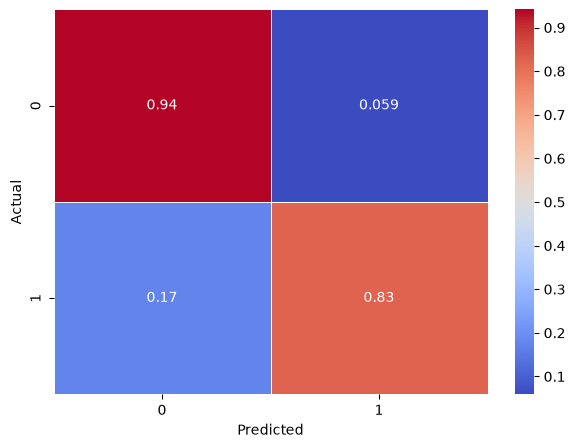

In [32]:
from common.evaluation_plots import show_norm_conf_mx

pred = modeling.predict_by_best_model(train.drop(['survived'], axis=1))

show_norm_conf_mx(y=train['survived'], pred=pred)

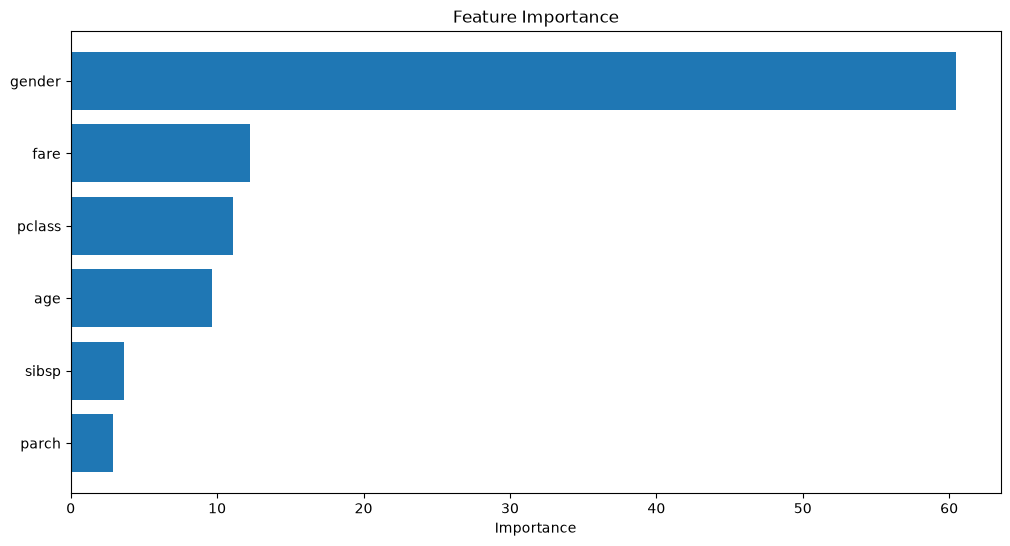

In [33]:
from common.modeling import BoostModelType

BoostModelType.show_plot_importance(modeling.get_best_model()['model'])

# Submission

In [34]:
bool_cols = test.select_dtypes(include=["bool", "boolean"]).columns
test[bool_cols] = test[bool_cols].astype("int8")

test[cat_cols] = test[cat_cols].astype('category')


In [39]:
pred = modeling.predict_by_best_model(test)

In [38]:
submission.shape , len(pred)

((393, 2), 393)

In [40]:
submission['survived'] = pred

submission.head()

,passengerid,survived
0,916,1
1,917,1
2,918,1
3,919,0
4,920,1


In [41]:
submission.to_csv("./submission/base_model_0909_012_(8436).csv", index=False)